<a href="https://colab.research.google.com/github/DaniloDuque/logistic-regression/blob/main/src/tp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP2 — Regresión Logística

## Setup

In [9]:
import os, sys

if 'google.colab' in sys.modules:
    if not os.path.exists('logistic-regression'):
        os.system('git clone https://github.com/DaniloDuque/logistic-regression.git')
    os.chdir('logistic-regression')

sys.path.insert(0, os.path.abspath('src'))

---
# Sección 1 — Algoritmo de Regresión Logística

## 1.a — Usar el código del perceptrón como base
DOCUMENTACION EN LATEX: Explique en el reporte cada una de las modificaciones necesarias al código del perceptrón, utilizando como referencia las diferencias entre ambos algoritmos.

### Pruebas unitarias
2 pruebas unitarias (con su objetivo, entradas, salidas esperadas y resultados) para las funciones modificadas en el algoritmo del perceptron base.

---
## 1.b — Experimentos: Datos separables vs no separables

### Imports

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import spacy
from pathlib import Path

from data_generator import generate_data
from logistic_regression import LogisticRegression
from trainer import train_with_history, compute_mae
from metrics import run_experiment, print_single_result, print_runs_table, compute_accuracy
from visualization import plot_results

STEPS = 1000
ALPHA = 0.1

FIGURES_DIR = Path(__file__).parent.parent / 'figures' if '__file__' in dir() else Path('..') / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)


### Experimento 1 — Datos linealmente separables

Dos clases generadas con `cluster_std=1.0` (grupos compactos y bien separados).
Se espera que el modelo converja rápidamente y obtenga un MAE bajo.


Iteraciones: 1000
Caso                           MAE Entren. MAE Prueba Acc Prueba
-----------------------------------------------------------------
Linealmente separable              0.0015     0.0006     1.0000


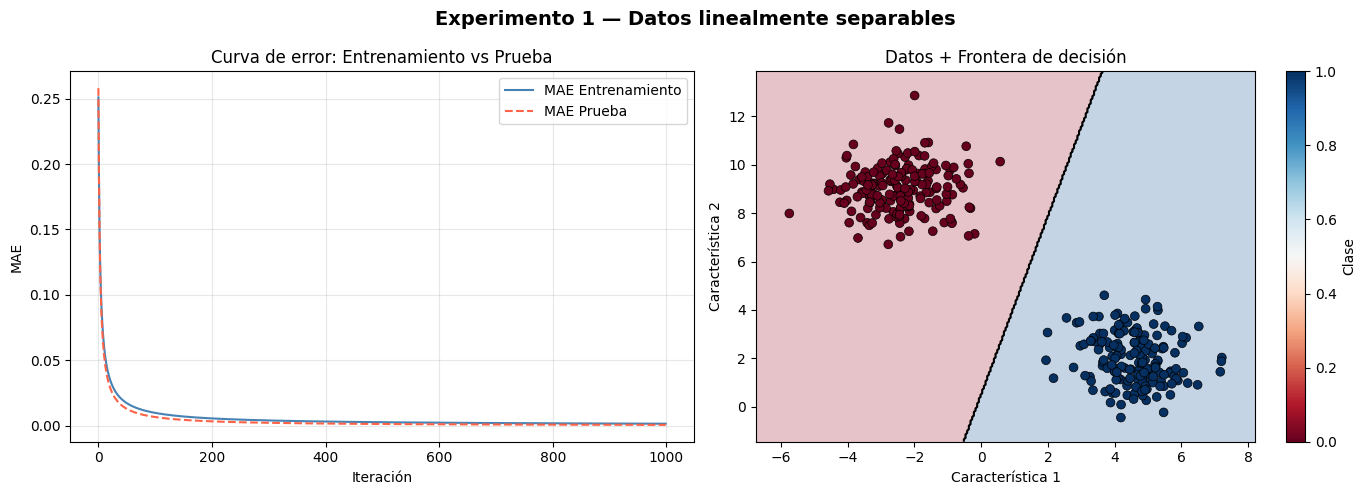

In [3]:
X_train_s, X_test_s, y_train_s, y_test_s = generate_data(separable=True, n_samples=500, random_state=42)

model_s = LogisticRegression(torch.zeros(X_train_s.shape[1], 1))
train_errors_s, test_errors_s = train_with_history(
    model_s, X_train_s, y_train_s, X_test_s, y_test_s, steps=STEPS, alpha=ALPHA
)

mae_train_s = compute_mae(y_train_s, model_s.forward(X_train_s))
mae_test_s  = compute_mae(y_test_s,  model_s.forward(X_test_s))
acc_train_s = compute_accuracy(model_s, X_train_s, y_train_s)
acc_test_s  = compute_accuracy(model_s, X_test_s,  y_test_s)

print(f"Iteraciones: {STEPS}")
print_single_result('Linealmente separable', mae_train_s, mae_test_s, acc_train_s, acc_test_s)

plot_results(model_s, X_train_s, y_train_s, train_errors_s, test_errors_s,
             'Experimento 1 — Datos linealmente separables',
             output_path=FIGURES_DIR / 'experimento1.pdf')


### Experimento 2 — Datos no linealmente separables

Dos clases generadas con `cluster_std=4.0` (grupos solapados).
Se espera que el modelo tenga dificultades y obtenga un MAE más alto.


Iteraciones: 1000
Caso                           MAE Entren. MAE Prueba Acc Prueba
-----------------------------------------------------------------
No linealmente separable           0.1789     0.1403     0.9267


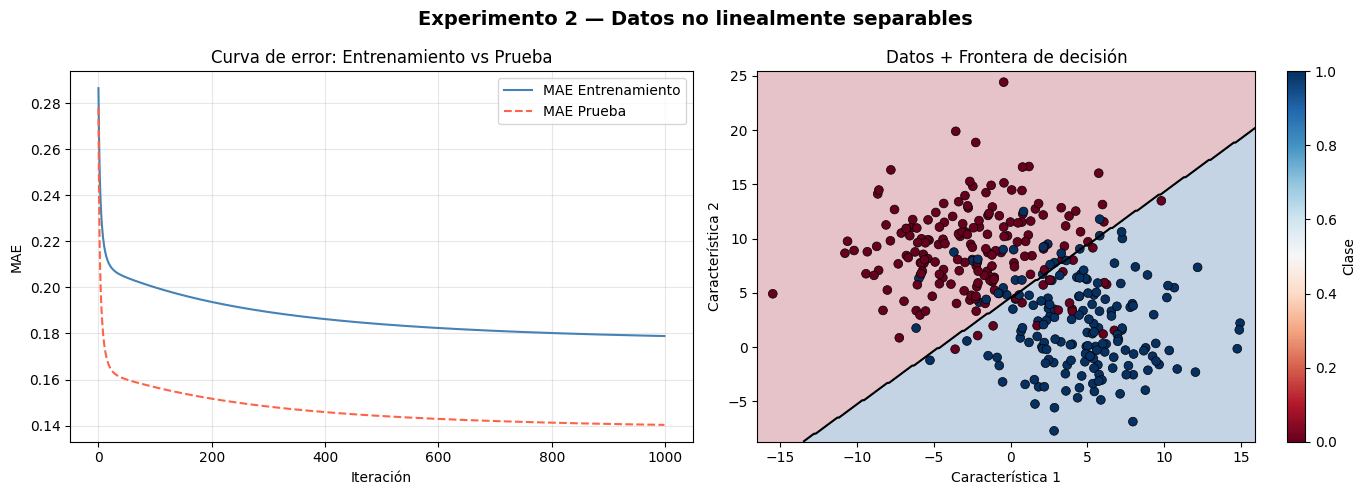

In [4]:
X_train_ns, X_test_ns, y_train_ns, y_test_ns = generate_data(separable=False, n_samples=500, random_state=42)

model_ns = LogisticRegression(torch.zeros(X_train_ns.shape[1], 1))
train_errors_ns, test_errors_ns = train_with_history(
    model_ns, X_train_ns, y_train_ns, X_test_ns, y_test_ns, steps=STEPS, alpha=ALPHA
)

mae_train_ns = compute_mae(y_train_ns, model_ns.forward(X_train_ns))
mae_test_ns  = compute_mae(y_test_ns,  model_ns.forward(X_test_ns))
acc_train_ns = compute_accuracy(model_ns, X_train_ns, y_train_ns)
acc_test_ns  = compute_accuracy(model_ns, X_test_ns,  y_test_ns)

print(f"Iteraciones: {STEPS}")
print_single_result('No linealmente separable', mae_train_ns, mae_test_ns, acc_train_ns, acc_test_ns)

plot_results(model_ns, X_train_ns, y_train_ns, train_errors_ns, test_errors_ns,
             'Experimento 2 — Datos no linealmente separables',
             output_path=FIGURES_DIR / 'experimento2.pdf')


### 1.2 — 10 ejecuciones: MAE medio, precisión, mínimo y máximo


In [5]:
results_s  = run_experiment(separable=True,  steps=STEPS, alpha=ALPHA)
results_ns = run_experiment(separable=False, steps=STEPS, alpha=ALPHA)

print_runs_table(results_s, results_ns)

Caso                          Media Desv.Típ      Mín      Máx
----------------------------------------------------------------------
MAE (prueba)
  Linealmente separable      0.0705   0.1356   0.0005   0.4684
  No linealmente separable   0.2759   0.1300   0.0924   0.4906
----------------------------------------------------------------------
Precisión (prueba)
  Linealmente separable      0.9407   0.1348   0.5400   1.0000
  No linealmente separable   0.7760   0.1368   0.5267   0.9467


---
# Sección 2 — Regresión Logística y LLMs para clasificación de textos

In [6]:
import pandas as pd
from huggingface_hub import hf_hub_download

file_path = hf_hub_download(
    repo_id="saul1917/FEINA",
    filename="FEINA_1.xlsx",
    repo_type="dataset"
)

df = pd.read_excel(file_path)
print(df.shape)
print(df.head())
print(df.columns.tolist())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


FEINA_1.xlsx:   0%|          | 0.00/808k [00:00<?, ?B/s]

(5313, 15)
   Unnamed: 0          idFinal  \
0           0  58_LibroBAC.pdf   
1           1  60_LibroBAC.pdf   
2           2  62_LibroBAC.pdf   
3           3  63_LibroBAC.pdf   
4           4  69_LibroBAC.pdf   

                                             Segment  \
0  Como antes explicamos, las finanzas y los conc...   
1  Una vez dirimidos estos asuntos, se entra de l...   
2  Pero aquí no termina la utilidad del libro, ya...   
3  Por lo demás, el libro en sí, termina siendo ú...   
4  Servir de documento de lectura y consulta sobr...   

                                            Proposal     idcod  atr0  atr1  \
0  Como antes explicamos, las finanzas están sust...  Fiorella  15.0  21.0   
1  Una vez resueltos estos asuntos, se abordan al...  Fiorella   1.0   5.0   
2  Pero aquí no termina la utilidad del libro, pu...  Fiorella  15.0  19.0   
3  Por lo demás, el libro es útil para personas p...  Fiorella   5.0  15.0   
4  Debe servir como documento de lectura y consul...  Fio

### Embeddings BERT — verificación de sanidad


In [7]:
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch
import numpy as np

# ── Modelo 1: BERT en español (dccuchile) ─────────────────────────
tokenizer1 = AutoTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")
model1 = AutoModelForMaskedLM.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")
model1.eval()

# ── Modelo 2: BERTIN - RoBERTa en español ─────────────────────────
tokenizer2 = AutoTokenizer.from_pretrained("bertin-project/bertin-roberta-base-spanish")
model2 = AutoModelForMaskedLM.from_pretrained("bertin-project/bertin-roberta-base-spanish")
model2.eval()

# ── Embedding mediante token CLS ──────────────────────────────────
def get_embedding(text, model, tokenizer):
    inputs = tokenizer(text, return_tensors="pt",
                       truncation=True, max_length=512, padding=True)
    with torch.no_grad():
        outputs = model.base_model(**inputs)
    return outputs.last_hidden_state[:, 0, :].squeeze().numpy()

# ── Verificación de sanidad ────────────────────────────────────────
test = "El índice de capitalización bursátil refleja la valoración agregada."
emb1 = get_embedding(test, model1, tokenizer1)
emb2 = get_embedding(test, model2, tokenizer2)

print(f"Modelo 1 (BERT-es) forma:   {emb1.shape}")
print(f"Modelo 2 (BERTIN) forma:    {emb2.shape}")


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

RobertaForMaskedLM LOAD REPORT from: bertin-project/bertin-roberta-base-spanish
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo 1 (BERT-es) forma:   (768,)
Modelo 2 (BERTIN) forma:    (768,)


## 1. Regresión logística con la TFIDF
### 1. a) Etapa de preprocesamiento
- Remueve stopwords
- Remueve puntuación
- Lematización
- Lo pasa a minúsculas

In [14]:
# PRUEBAAAA
import spacy

nlp = spacy.load("en_core_web_sm")

def preprocess_text(text):
    doc = nlp(text.lower())

    tokens = []

    for token in doc:
        # Ignorar puntuación (.is_punct), espacios (.is_space) y stopwords
        if token.is_stop or token.is_punct or token.is_space:
            continue

        lemma = token.lemma_.strip() # Se usa Lemma

        if lemma:
            tokens.append(lemma)

    return " ".join(tokens)

text = "The students were studying logistic regression models."

print(preprocess_text(text))

student study logistic regression model
